# Figure creation

The goal of this notebook is to generate and save figures used in the report and powerpoint presentations.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
#import pyccl as ccl

from simulMap import *
from lumMag_sampling import *
from cluster import *
from fitMap import *
from mappers import DepthMapper, CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Dipole creation

Saving NoMonop_ValuesTitle in Simul_Figures/Simul_Dip/Dip_NoMonop_ValuesTitle.pdf
Saving NoMonop in Simul_Figures/Simul_Dip/Dip_NoMonop.pdf


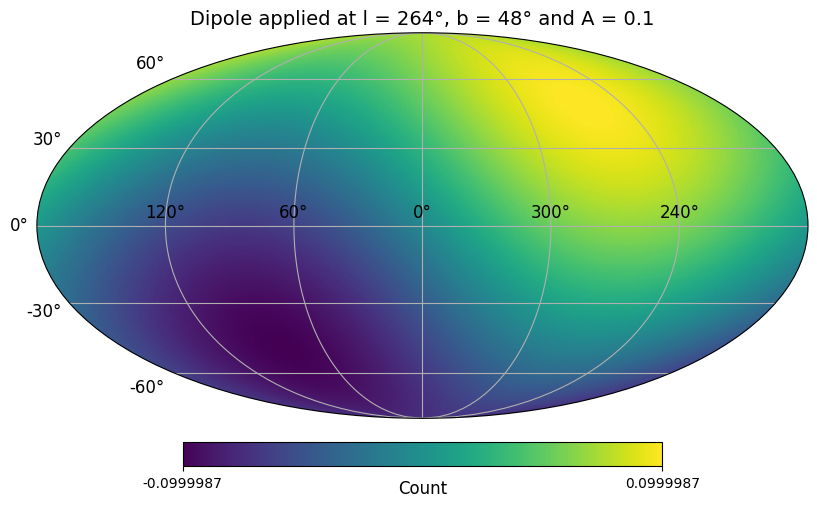

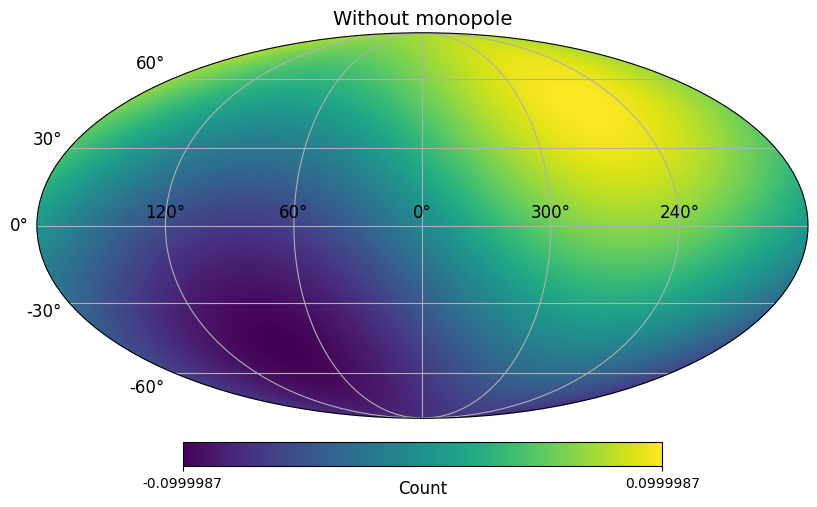

In [11]:
nest = True
A, l, b = 0.1, 264, 48
NSource_px_dipole = apply_dipole_Alb(np.arange(npix), A, l, b, nest)

dipoleMapper = CountMapper.from_map(NSource_px_dipole, nest=nest)
dipoleMapper._set_instance_settingsPlot(xlabel="", ylabel="")
dipoleMapper.plot(title=f"Dipole applied at l = {l}°, b = {b}° and A = {A}")

output_path = "Simul_Figures/Simul_Dip/Dip_"
get_savefig(plt, output_path, "NoMonop_ValuesTitle")

dipoleMapper.plot(title="Without monopole")
get_savefig(plt, output_path, "NoMonop")

## Monopole creation

Saving NoVar_ValuesTitle in Simul_Figures/Simul_Monop/Monop_NoVar_ValuesTitle.pdf
Saving NoVar in Simul_Figures/Simul_Monop/Monop_NoVar.pdf


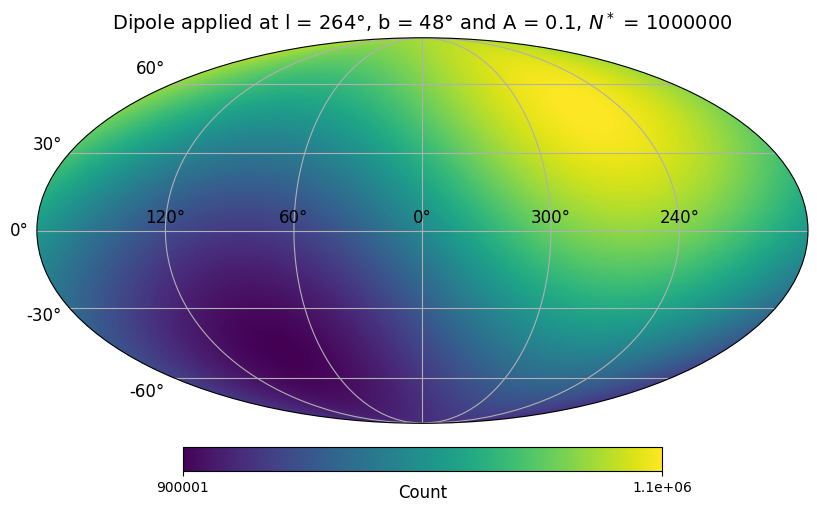

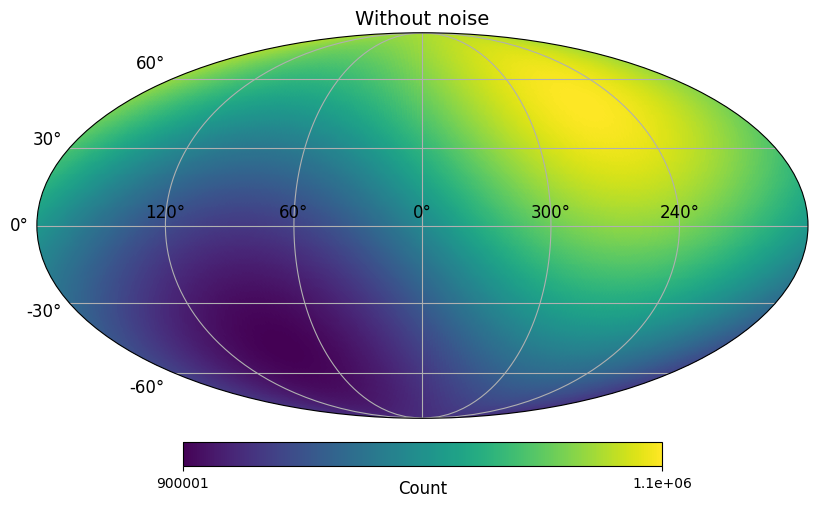

In [12]:
NSource_px_dipole_lb = NSource_px_th*(1 + NSource_px_dipole)
monopMapper = CountMapper.from_map(NSource_px_dipole_lb, nest=nest)
monopMapper._set_instance_settingsPlot(xlabel="", ylabel="")

title = f"Dipole applied at l = {l}°, b = {b}° and A = {A}, $N^*$ = {NSource_px_th}"
monopMapper.plot(title=title)
output_path = "Simul_Figures/Simul_Monop/Monop_"
get_savefig(plt, output_path, "NoVar_ValuesTitle")

title = "Without noise"
monopMapper.plot(title=title)
output_path = "Simul_Figures/Simul_Monop/Monop_"
get_savefig(plt, output_path, "NoVar")

## Adding Shot noise

Saving PoissVar_ValuesTitle in Simul_Figures/Simul_Monop/Monop_PoissVar_ValuesTitle.pdf
Saving PoissVar in Simul_Figures/Simul_Monop/Monop_PoissVar.pdf


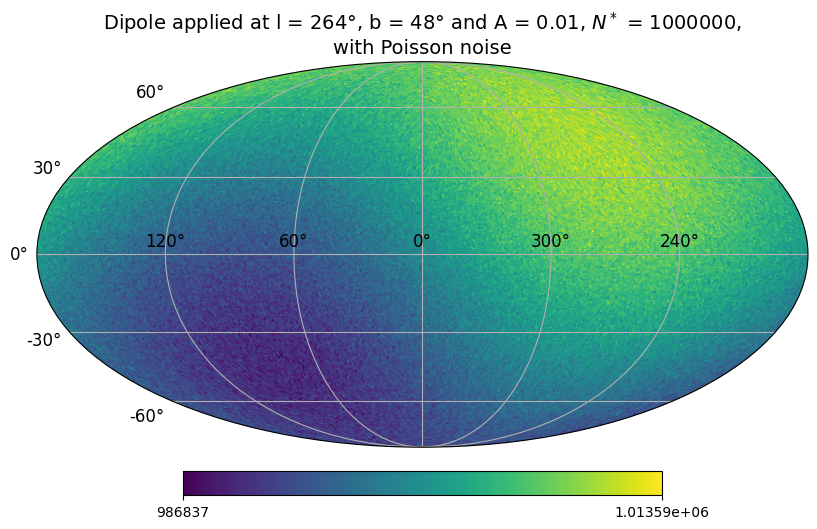

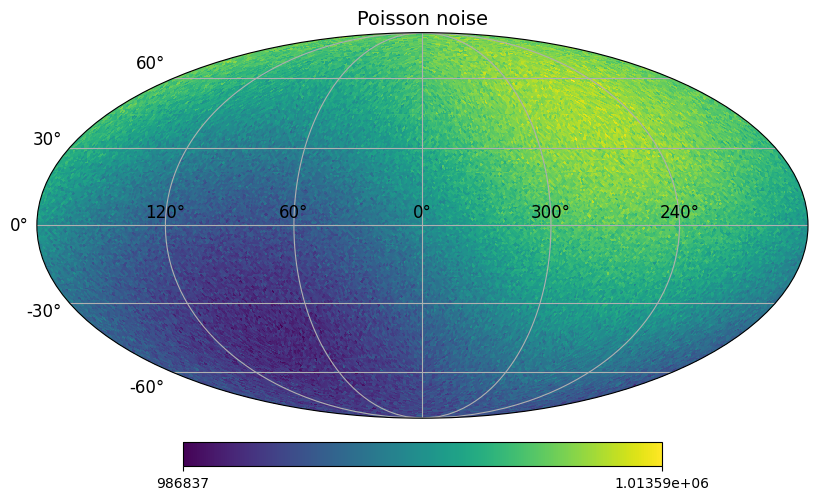

In [5]:
NSource_px_var_lb = np.random.poisson(NSource_px_dipole_lb)

title = f"Dipole applied at l = {l}°, b = {b}° and A = {A}, $N^*$ = {NSource_px_th},\nwith Poisson noise"
hp.projview(NSource_px_var_lb, title=title, graticule=True, graticule_labels=True)
output_path = "Simul_Figures/Simul_Monop/Monop_"
get_savefig(plt, output_path, "PoissVar_ValuesTitle")

title = "Poisson noise"
hp.projview(NSource_px_var_lb, title=title, graticule=True, graticule_labels=True)
output_path = "Simul_Figures/Simul_Monop/Monop_"
get_savefig(plt, output_path, "PoissVar")

## Power spectrum

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


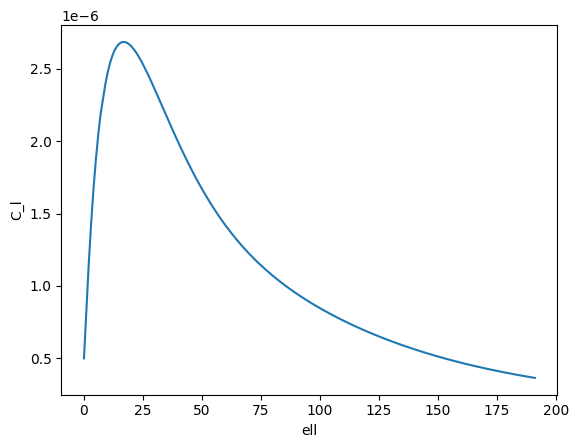

In [5]:
cl, ell = get_Cl_ccl(nside, 0, get_ell=True)
plt.plot(ell, cl)
plt.xlabel('ell')
plt.ylabel('C_l');

### With log-normal

Saving NoVar in Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_NoVar.pdf


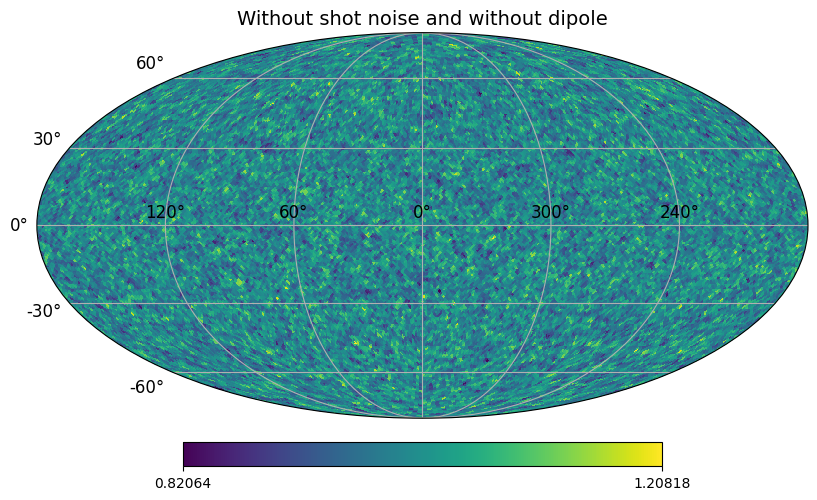

In [7]:
lognormal=True
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="Without shot noise and without dipole"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_"
get_savefig(plt, output_path, "NoVar")

Saving PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_PoissVar.pdf


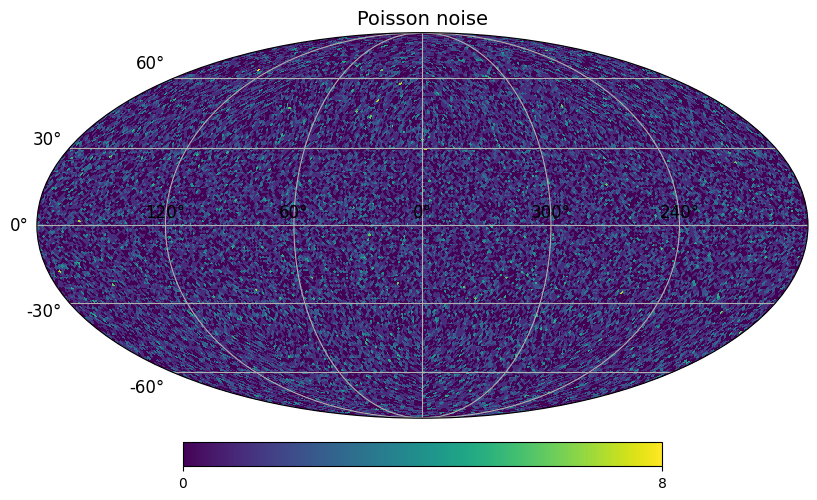

In [8]:
NSource_px__var_Cl = np.random.poisson(NSource_px_Cl)
title="Poisson noise"
hp.projview(NSource_px__var_Cl, title=title, graticule=True, graticule_labels=True)
output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_"
get_savefig(plt, output_path, "PoissVar")

Saving Dip in Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_Dip.pdf


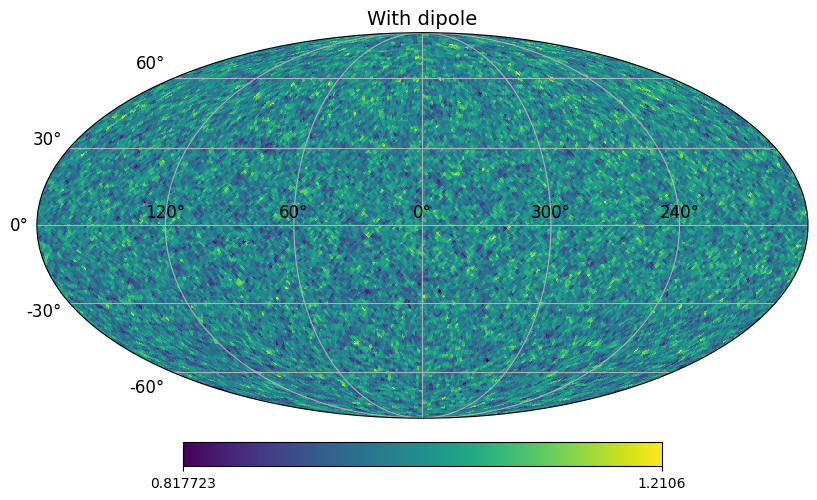

In [9]:
NSource_px_Cl_dip = NSource_px_Cl + NSource_px_dipole

title="With dipole"
hp.projview(NSource_px_Cl_dip, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_"
get_savefig(plt, output_path, "Dip")

Saving DipMonop in Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_DipMonop.pdf


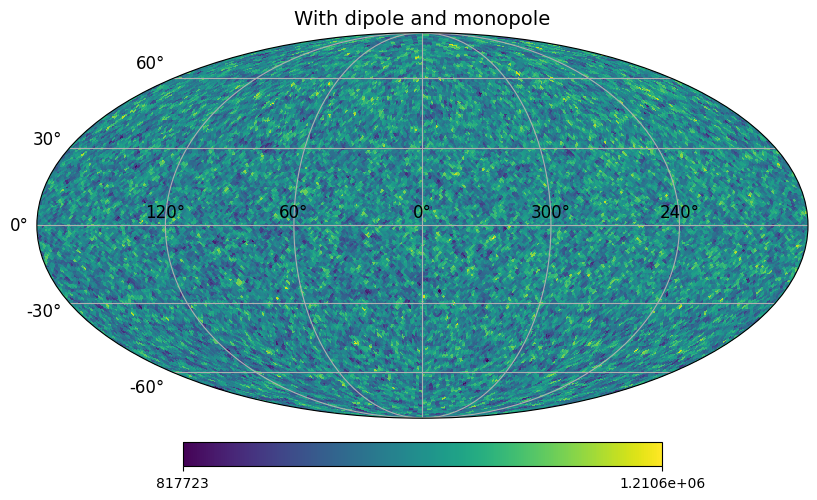

In [10]:
NSource_px_Cl_monop = NSource_px_th*NSource_px_Cl_dip

title="With dipole and monopole"
hp.projview(NSource_px_Cl_monop, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_"
get_savefig(plt, output_path, "DipMonop")

Saving DipMonop_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_DipMonop_PoissVar.pdf


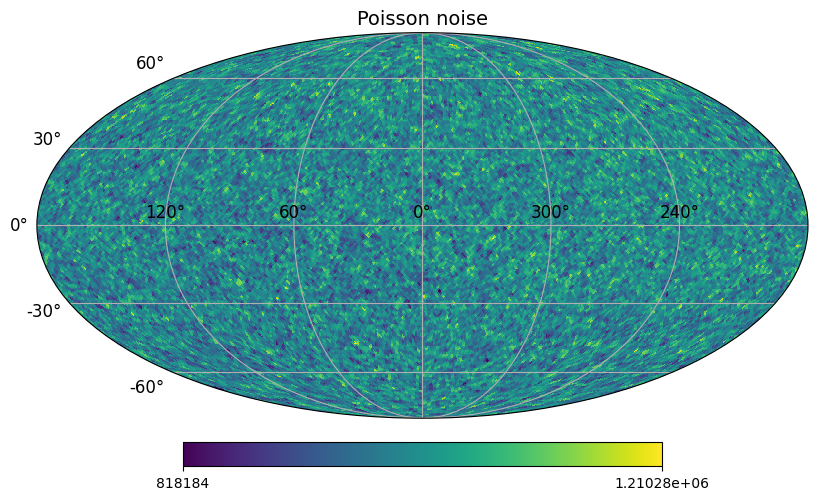

In [11]:
NSource_px_Cl_var_monop =np.random.poisson(NSource_px_Cl_monop)

title="Poisson noise"
hp.projview(NSource_px_Cl_var_monop, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_logNorm/Cluster_logNorm_"
get_savefig(plt, output_path, "DipMonop_PoissVar")

### Without log-normal

Saving NoVar in Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_NoVar.pdf


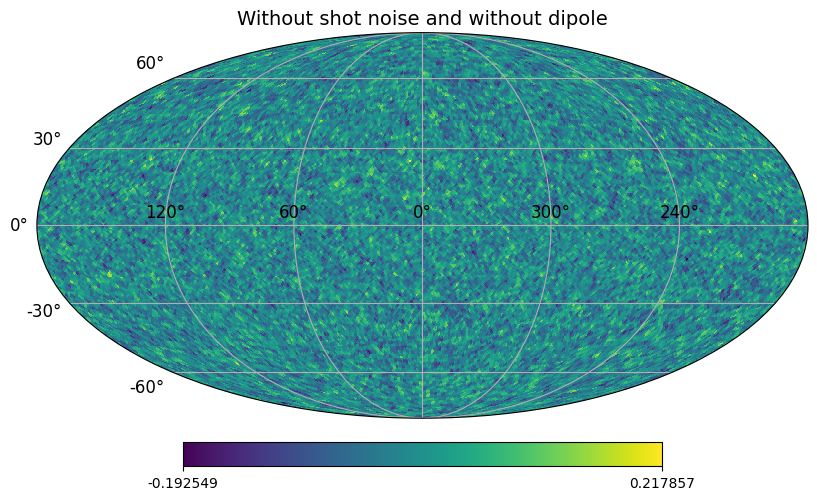

In [6]:
lognormal=False
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="Without shot noise and without dipole"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_"
get_savefig(plt, output_path, "NoVar")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1852 (χ²/ndof = 0.0)       │              Nfcn = 333              │
│ EDM = 1.77e-06 (Goal: 0.0002)    │            time = 3.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ A    │  0.11e-3  │  0.78e-3  │  -0.10e-3  │  0.59e-3   │    0    │    1    │       │
│ 1 │ l    │  0.14e3   │  0.24e3   │  -0.14e3   │   0.22e3   │    0    │   360   │       │
│ 2 │ b    │    -0     │    110    │    -90     │     90     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.10e-3  │  0.59e-3  │  -0.14e3  │  0.22e3   │    -90    │    90     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬────────────────────────────────────────┐
│   │            A            l            b │
├───┼────────────────────────────────────────┤
│ A │     3.26e-07 -24.33238e-3  -3.06030e-3 │
│ l │ -24.33238e-3     9.71e+04       0.01e6 │
│ b │  -3.06030e-3       0.01e6     1.01e+05 │
└───┴────────────────────────────────────────┘

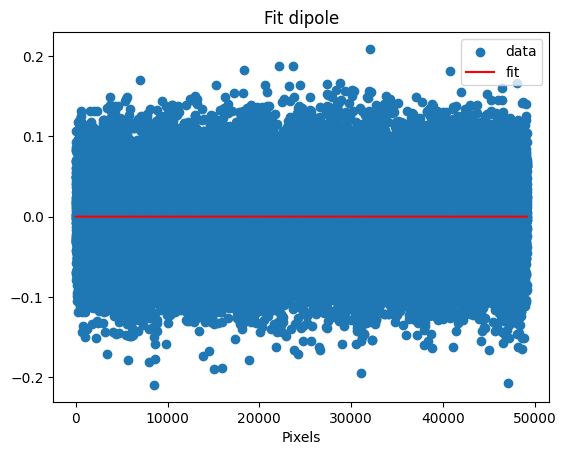

In [42]:
model = lambda map, A, ra, dec : apply_dipole_Alb(map, A, ra, dec, nest=False)
init =  (0, 20, 40)
names = ("A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl, init, names, bounds=([0, 0, -90], [1, 360, 90]))
m

Saving Dip in Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_Dip.pdf


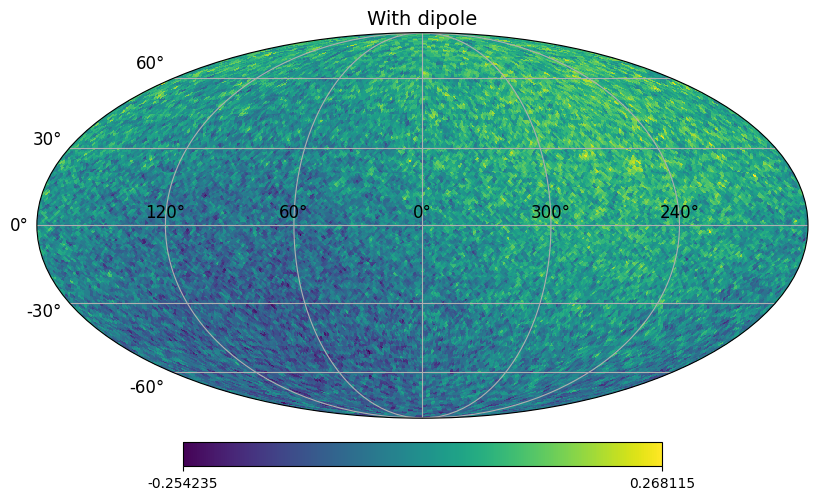

In [7]:
NSource_px_Cl_dip = NSource_px_Cl + NSource_px_dipole

title="With dipole"
hp.projview(NSource_px_Cl_dip, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_"
get_savefig(plt, output_path, "Dip")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1864 (χ²/ndof = 0.0)       │              Nfcn = 526              │
│ EDM = 5.47e-06 (Goal: 0.0002)    │            time = 4.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  0.11e-3  │  0.22e-3  │  -0.11e-3  │  0.22e-3   │    0    │         │       │
│ 1 │ A    │999.9983e-3│971.5773e-3│-999.9983e-3│ 0.0017e-3  │    0    │    1    │       │
│ 2 │ l    │    280    │    270    │    -280    │     80     │    0    │   360   │       │
│ 3 │ b    │    57     │    144    │    -147    │     33     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.11e-3  │  0.22e-3  │-999998.3e-6│  1.7e-6   │   -280    │    80     │   -147    │    33     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────────────┐
│    │         N*          A          l          b │
├────┼─────────────────────────────────────────────┤
│ N* │   4.63e-08         -0 7.96162e-3 1.60141e-3 │
│  A │         -0   1.18e-05  -0.117e-3  -0.035e-3 │
│  l │ 7.96162e-3  -0.117e-3   2.61e+04        1e3 │
│  b │ 1.60141e-3  -0.035e-3        1e3   8.13e+03 │
└────┴─────────────────────────────────────────────┘

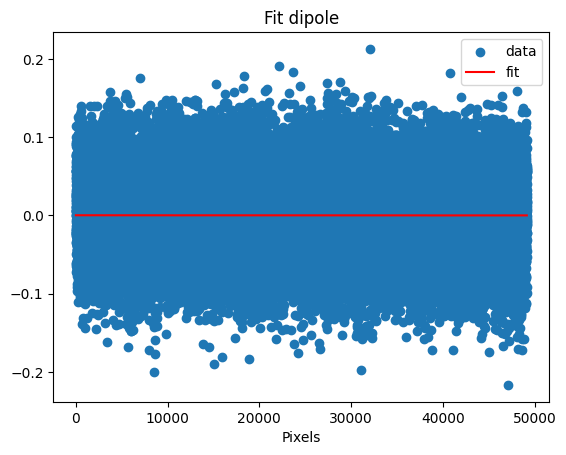

In [43]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs', contrast=False)
init =  (0, 1, 200, 40)
names = ("N*", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl_dip, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

Saving DipMonop in Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_DipMonop.pdf


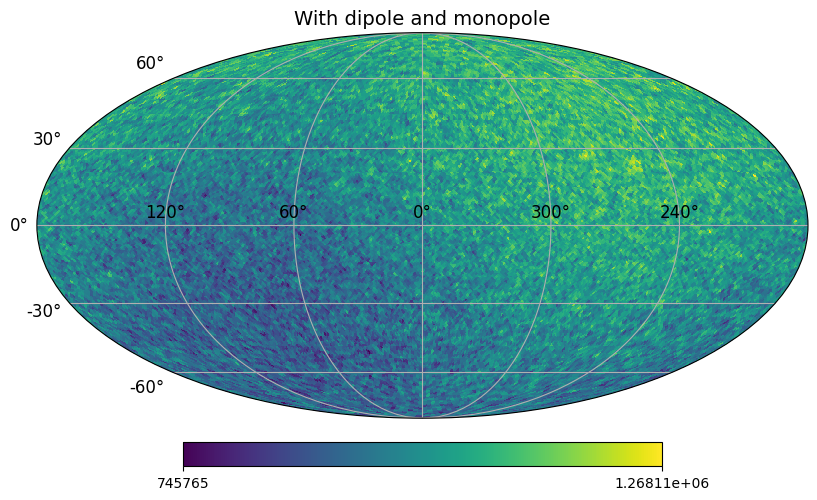

In [8]:
NSource_px_Cl_monop = NSource_px_th*(1 + NSource_px_Cl_dip)

title="With dipole and monopole"
hp.projview(NSource_px_Cl_monop, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_"
get_savefig(plt, output_path, "DipMonop")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.107e+08 (χ²/ndof = 2251.7)│              Nfcn = 270              │
│ EDM = 1.41e-05 (Goal: 0.0002)    │            time = 3.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 997.841e3 │  0.005e3  │  -0.005e3  │  0.004e3   │    0    │         │       │
│ 1 │ A    │ 99.954e-3 │ 0.008e-3  │ -0.008e-3  │  0.008e-3  │    0    │    1    │       │
│ 2 │ l    │  263.458  │   0.007   │   -0.007   │   0.007    │    0    │   360   │       │
│ 3 │ b    │  48.151   │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -5     │     4     │   -8e-6   │   8e-6    │  -0.007   │   0.007   │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────┐
│    │       N*        A        l        b │
├────┼─────────────────────────────────────┤
│ N* │     20.3 -0.81e-9       -0       -0 │
│  A │ -0.81e-9 6.08e-11 -0.01e-9 -0.02e-9 │
│  l │       -0 -0.01e-9 4.51e-05        0 │
│  b │       -0 -0.02e-9        0 2.01e-05 │
└────┴─────────────────────────────────────┘

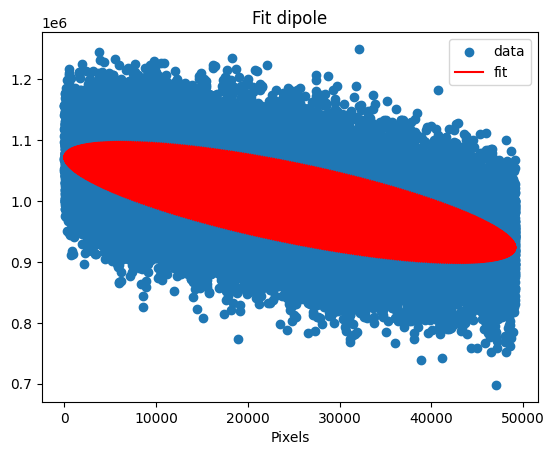

In [30]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs', contrast=False)
init =  (1e5, 0, 200, 40)
names = ("N*", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl_monop, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

Saving DipMonop_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_DipMonop_PoissVar.pdf


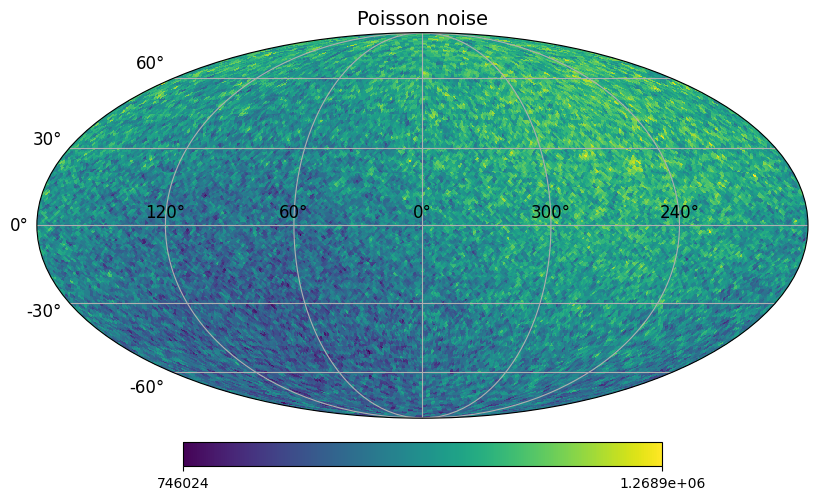

In [9]:
NSource_px_Cl_var_monop =np.random.poisson(NSource_px_Cl_monop)

title="Poisson noise"
hp.projview(NSource_px_Cl_var_monop, title=title, graticule=True, graticule_labels=True)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_"
get_savefig(plt, output_path, "DipMonop_PoissVar")